# YOLOv11 on NFL Helmets (Single View)
YOLOv11 is a state-of-the-art object detection model that has been continually developed from the early days.

Using bounding box data for NFL Helmets from actual NFL plays, we will finetune a YOLOv11 model to detect helmets in still images. The data has two different views, the **endzone** and the **sideline** views. To keep things simple, we will train separate models for each view, and see how they perform. The expected outputs are bounding boxes that correspond to all helmets in the image.

The original data is [housed on Kaggle](https://www.kaggle.com/competitions/nfl-health-and-safety-helmet-assignment/overview) and has both video data and image data. While we can use this on videos, we have more clear training data from the images, so we will start with that.

## Import Packages

In [12]:
import sys

# From RF-DETR developers (Roboflow)
from ultralytics import YOLO
import supervision as sv

import numpy as np
import polars
import os
import glob
import shutil
import itertools
import yaml

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm
import cv2

RANDOM_SEED = 1729
TEST_SIZE = 0.2

DATA_DIR = os.path.join('../data', 'nfl-health-and-safety-helmet-assignment')
DATASET_DIR = os.path.join(DATA_DIR, 'nfl_helmet_image_dataset')


## Training on Still Images
Before we jump straight into training, we will train on the provided ~10000 images. We need to place these images in the right format. This includes structuring our directories correctly, and representing the bounding box data correctly as well.

Originally, the images are located in the top-level directroy with `./data/nfl-health-and-safety-health-assignment`. We will create another folder here and establish the format.

```text
dataset/
└── Endzone/  # We will have a directory for the endzone and sideline views separately.
    ├── images/
    │   ├── train/
    │   │   ├── 000000000009.jpg
    │   │   └── ...
    │   └── valid/
    │       └── ...
    └── labels/
        ├── train/  # Training labels
        │   ├── 000000000009.txt
        │   └── ...
        └── valid/
            └── ...
```

For the `*.txt` files under the labels directory, each text file corresponds to one image, and contains all the bounding boxes that are present in that image. Each row has the format `class_index  x_center  y_center  width  height`, where
the center coordinates and width-height measurements are **normalized** to be between 0 and 1. In our case, since we only have helmets to detect, the class index will always be 0.

### Putting Images into Structure
We will follow the structure above and **move** the files (so we don't take up doulbe the storage space). We will also create two separate datasets for the endzone and sideline views, since they are fundamentally different views Calthough they are of the same scene).

In [2]:
ENDZONE_DIR = os.path.join(DATASET_DIR, 'Endzone')
SIDELINE_DIR = os.path.join(DATASET_DIR, 'Sideline')
os.makedirs(ENDZONE_DIR, exist_ok=True)
os.makedirs(SIDELINE_DIR, exist_ok=True)
# Create the directories. We will just have a train and test datasets.
# First find the split...
for view, directory in zip(['Endzone', 'Sideline'], [ENDZONE_DIR, SIDELINE_DIR]):
    print(f'Gathering the {view} view...')
    all_og_image_files = glob.glob(os.path.join(DATA_DIR, 'images', f'*{view}*.jpg'))
    # Create a train test split. Make it reproducible...
    train, valid = train_test_split(all_og_image_files, test_size=TEST_SIZE, random_state=RANDOM_SEED)
    print('Training images:', len(train))
    print('Validation images:', len(valid))
    # Move the files to the sub-directory (/train or /test)
    # and create both images/train and labels/train
    for dirname, dataset in zip(['train', 'valid'], [train, valid]):
        os.makedirs(os.path.join(directory, 'images', dirname), exist_ok=True)
        os.makedirs(os.path.join(directory, 'labels', dirname), exist_ok=True)
        for file in tqdm(dataset, desc=f'Moving {dirname} files'):
            shutil.move(file, os.path.join(directory, 'images', dirname, os.path.basename(file)))
    print()

Gathering the Endzone view...
Training images: 3991
Validation images: 998


Moving train files:   0%|          | 0/3991 [00:00<?, ?it/s]

Moving valid files:   0%|          | 0/998 [00:00<?, ?it/s]


Gathering the Sideline view...
Training images: 3966
Validation images: 992


Moving train files:   0%|          | 0/3966 [00:00<?, ?it/s]

Moving valid files:   0%|          | 0/992 [00:00<?, ?it/s]

### Creating Bounding Box Text Files
Now that the images are in the right structure, we need to create the text files which have the bounding box data. The bounding box data is in the `image_labels.csv` file, and are represented by the *top-left corner* and its width and height. We need to convert the coordinates to have the center, and also normalize the values.

For the purposes of this project, we just have one kind of annotation, the helmet. In our ground truth labeling, we have `Helmet`, `Helmet-Blurred`, `Helmet-Difficult`, and `Helmet-Sideline`. We will consolidate all of these into a single `Helmet` label.

In [2]:
image_labels = polars.read_csv(os.path.join(DATA_DIR, 'image_labels.csv'))
print(image_labels.head())
print(image_labels.shape)

shape: (5, 6)
┌─────────────────────────────────┬────────┬──────┬───────┬─────┬────────┐
│ image                           ┆ label  ┆ left ┆ width ┆ top ┆ height │
│ ---                             ┆ ---    ┆ ---  ┆ ---   ┆ --- ┆ ---    │
│ str                             ┆ str    ┆ i64  ┆ i64   ┆ i64 ┆ i64    │
╞═════════════════════════════════╪════════╪══════╪═══════╪═════╪════════╡
│ 57503_000116_Endzone_frame443.… ┆ Helmet ┆ 1099 ┆ 16    ┆ 456 ┆ 15     │
│ 57503_000116_Endzone_frame443.… ┆ Helmet ┆ 1117 ┆ 15    ┆ 478 ┆ 16     │
│ 57503_000116_Endzone_frame443.… ┆ Helmet ┆ 828  ┆ 16    ┆ 511 ┆ 15     │
│ 57503_000116_Endzone_frame443.… ┆ Helmet ┆ 746  ┆ 16    ┆ 519 ┆ 16     │
│ 57503_000116_Endzone_frame443.… ┆ Helmet ┆ 678  ┆ 17    ┆ 554 ┆ 17     │
└─────────────────────────────────┴────────┴──────┴───────┴─────┴────────┘
(193736, 6)


In [3]:
structured_files = glob.glob(os.path.join(DATASET_DIR, '**/*.jpg'), recursive=True)
filenames = [os.path.basename(file) for file in structured_files]
dirnames = [os.path.basename(os.path.dirname(file)) for file in structured_files]
get_train_test = lambda filename: dirnames[filenames.index(os.path.basename(filename))]
image_labels = image_labels.with_columns(
    polars.when(polars.col('image').str.contains('Endzone'))
        .then(polars.lit('Endzone'))
        .otherwise(polars.lit('Sideline'))
        .alias('view'),
    polars.col('image').map_elements(get_train_test, return_dtype=polars.String).alias('split')
)
print(image_labels.head())

shape: (5, 8)
┌─────────────────────────────────┬────────┬──────┬───────┬─────┬────────┬─────────┬───────┐
│ image                           ┆ label  ┆ left ┆ width ┆ top ┆ height ┆ view    ┆ split │
│ ---                             ┆ ---    ┆ ---  ┆ ---   ┆ --- ┆ ---    ┆ ---     ┆ ---   │
│ str                             ┆ str    ┆ i64  ┆ i64   ┆ i64 ┆ i64    ┆ str     ┆ str   │
╞═════════════════════════════════╪════════╪══════╪═══════╪═════╪════════╪═════════╪═══════╡
│ 57503_000116_Endzone_frame443.… ┆ Helmet ┆ 1099 ┆ 16    ┆ 456 ┆ 15     ┆ Endzone ┆ train │
│ 57503_000116_Endzone_frame443.… ┆ Helmet ┆ 1117 ┆ 15    ┆ 478 ┆ 16     ┆ Endzone ┆ train │
│ 57503_000116_Endzone_frame443.… ┆ Helmet ┆ 828  ┆ 16    ┆ 511 ┆ 15     ┆ Endzone ┆ train │
│ 57503_000116_Endzone_frame443.… ┆ Helmet ┆ 746  ┆ 16    ┆ 519 ┆ 16     ┆ Endzone ┆ train │
│ 57503_000116_Endzone_frame443.… ┆ Helmet ┆ 678  ┆ 17    ┆ 554 ┆ 17     ┆ Endzone ┆ train │
└─────────────────────────────────┴────────┴──────┴─────

We are ready to do the bounding box labels. Below is what each file should look like. The is the first training image in the COCO128 dataset.

```text
45 0.479492 0.688771 0.955609 0.5955
45 0.736516 0.247188 0.498875 0.476417
50 0.637063 0.732938 0.494125 0.510583
45 0.339438 0.418896 0.678875 0.7815
49 0.646836 0.132552 0.118047 0.0969375
49 0.773148 0.129802 0.0907344 0.0972292
49 0.668297 0.226906 0.131281 0.146896
49 0.642859 0.0792187 0.148063 0.148062
```

The first line corresponds to a bounding box with class label of 45 (which is a bowl) with box center (0.479, 0.689) and whose width and height are 0.956 and 0.596 respectively.

The main key is that the filename of each text file needs to match that of the image it is representing.

In [6]:
for view, split in itertools.product(['Endzone', 'Sideline'], ['train', 'valid']):
    # Filter the dataframe according to the view and split.
    dataset_view_split = image_labels.filter(
        polars.col('view').eq(view),
        polars.col('split').eq(split),
    )
    # Get all the files for this view
    image_filenames = dataset_view_split.unique('image')['image'].to_list()
    # Iterate through the list.
    # For each image, get its bounding boxes, the full image width and height,
    # grab the center, and normalize.
    # Then convert to numpy and save it all at once.
    for image in tqdm(image_filenames, desc=f'Generating bounding box files for {view} ({split})'):
        image_boxes = dataset_view_split.filter(
            polars.col('image').eq(image),
        )
        # Read the image for its width and height
        image_obj = cv2.imread(os.path.join(DATASET_DIR, view, 'images', split, image))
        # Width and height are reversed!
        # The number of rows is the height, while the number of columns is the width
        height, width = image_obj.shape[:2]
        image_boxes: np.ndarray = image_boxes[['left', 'top', 'width', 'height']].to_numpy().astype(float)
        print(image_boxes)
        # Convert top-left box coordinate to center coordinate
        image_boxes[:, 0] += image_boxes[:, 2] / 2
        image_boxes[:, 1] += image_boxes[:, 3] / 2
        print(image_boxes)
        # Divide the x-center and the box-width by the full image width,
        # and divide the y-center and the box-height by the full image height.
        image_boxes[:, [0, 2]] /= width
        image_boxes[:, [1, 3]] /= height
        print(image_boxes)
        sys.exit(1)
        # Box conversion is done, save the text file with the same name! (remove the extension)
        # Concatenate a column of zeroes to represent our single class ID
        image_boxes = np.concat((np.zeros(image_boxes.shape[0])[:, np.newaxis], image_boxes), 1)
        np.savetxt(os.path.join(DATASET_DIR, view, 'labels', split, f'{os.path.splitext(image)[0]}.txt'), image_boxes,
                   delimiter=' ', fmt='%.7f')


Generating bounding box files for Endzone (train):   0%|          | 0/3991 [00:00<?, ?it/s]

[[        961         120          19          19]
 [        615         237          19          20]
 [        620         275          18          23]
 [        615         253          19          14]
 [        361         215          19          19]
 [        323         128          16          15]
 [        351          79          14          18]
 [        316          96          16          19]
 [        207         287          17          15]
 [         50         411          20          19]
 [          0         384          18          23]
 [          0         369          11          17]]
[[      970.5       129.5          19          19]
 [      624.5         247          19          20]
 [        629       286.5          18          23]
 [      624.5         260          19          14]
 [      370.5       224.5          19          19]
 [        331       135.5          16          15]
 [        358          88          14          18]
 [        324       105.5     

SystemExit: 1

### Validating and Visualizing
Now that the conversion has finished, we will plot a sample of images to make sure everything worked as intended. To easily plot them, we will use the `supervision` package and its built-in plotting capabilities.

Plotting a sample 2 samples from Endzone (train)


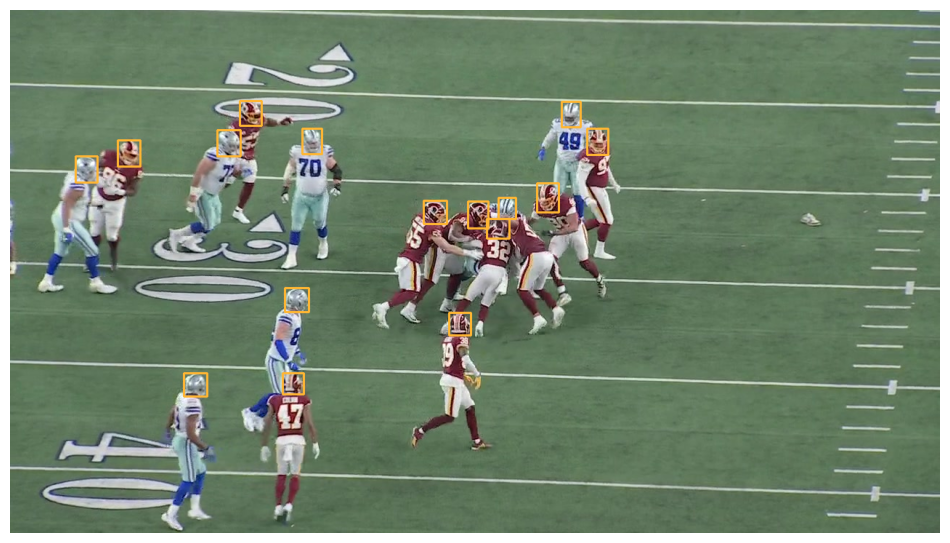

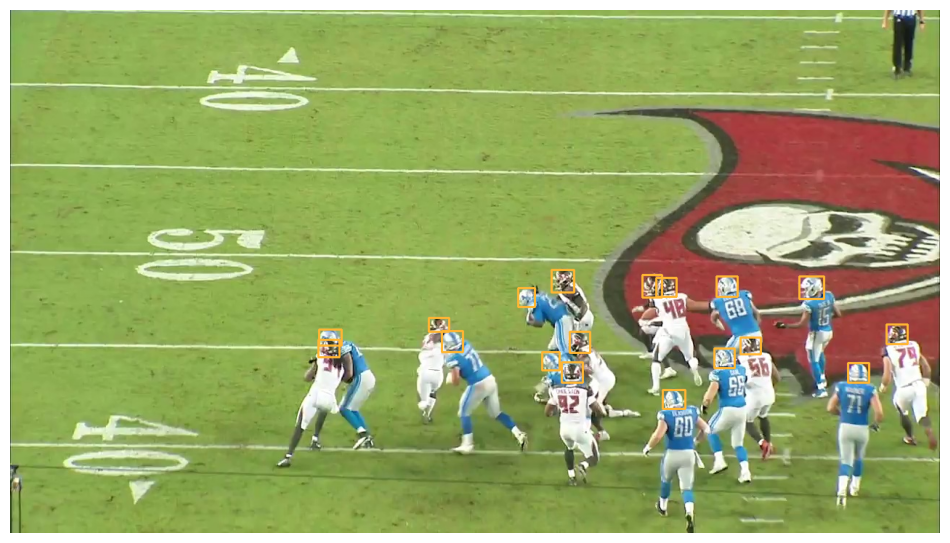


Plotting a sample 2 samples from Endzone (valid)


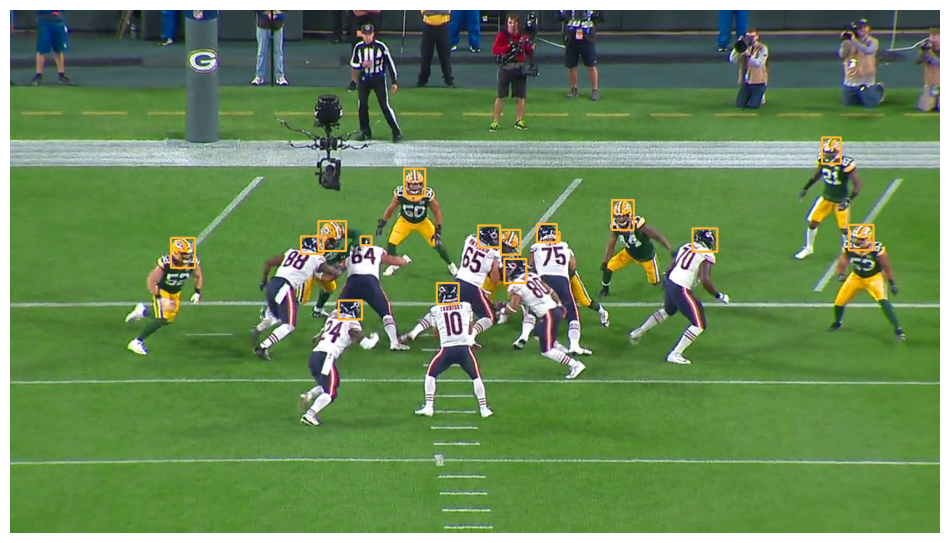

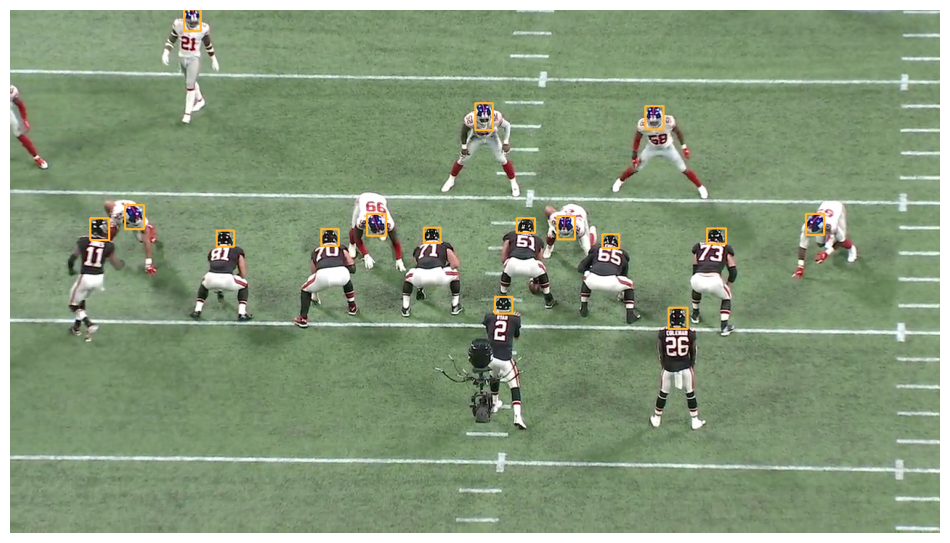


Plotting a sample 2 samples from Sideline (train)


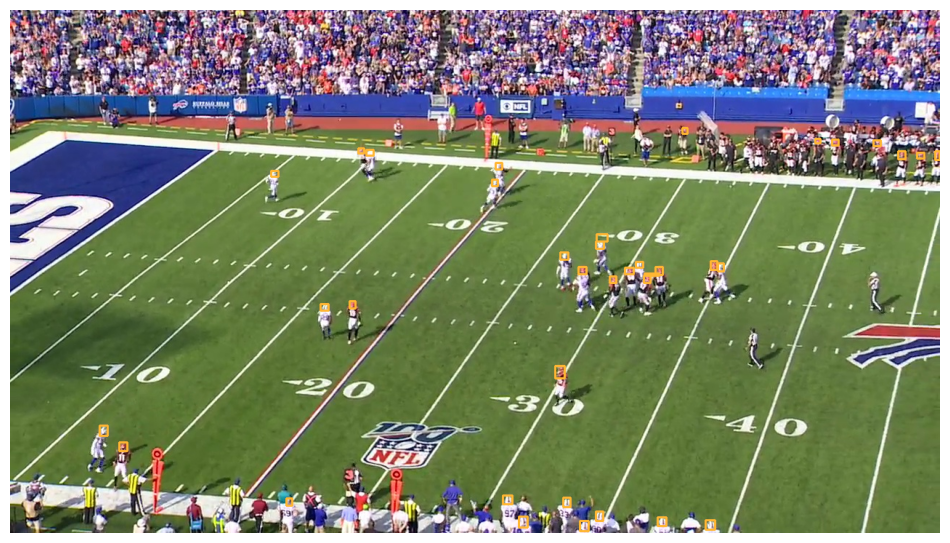

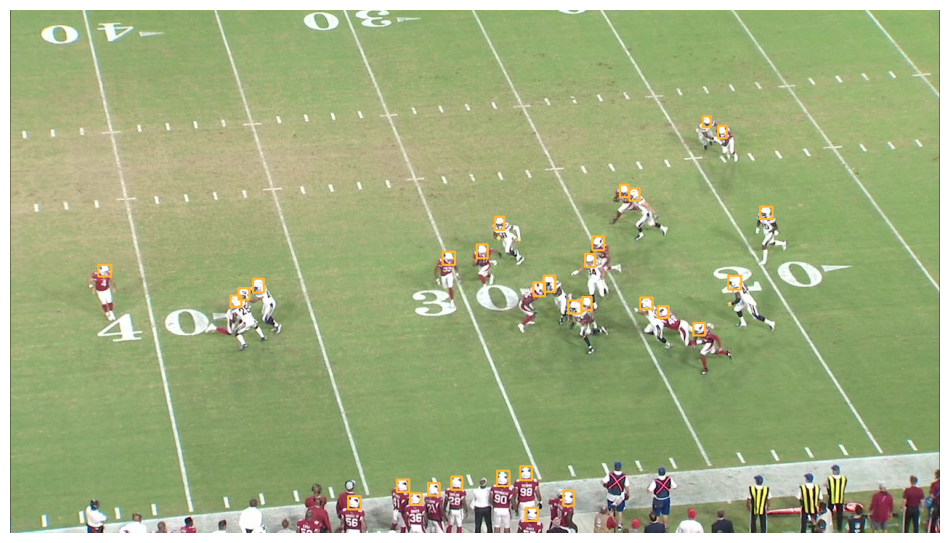


Plotting a sample 2 samples from Sideline (valid)


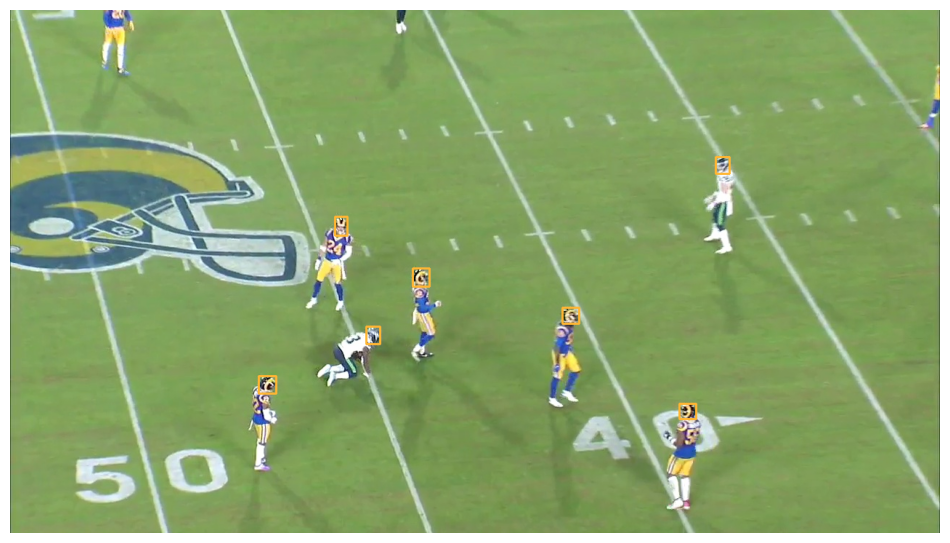

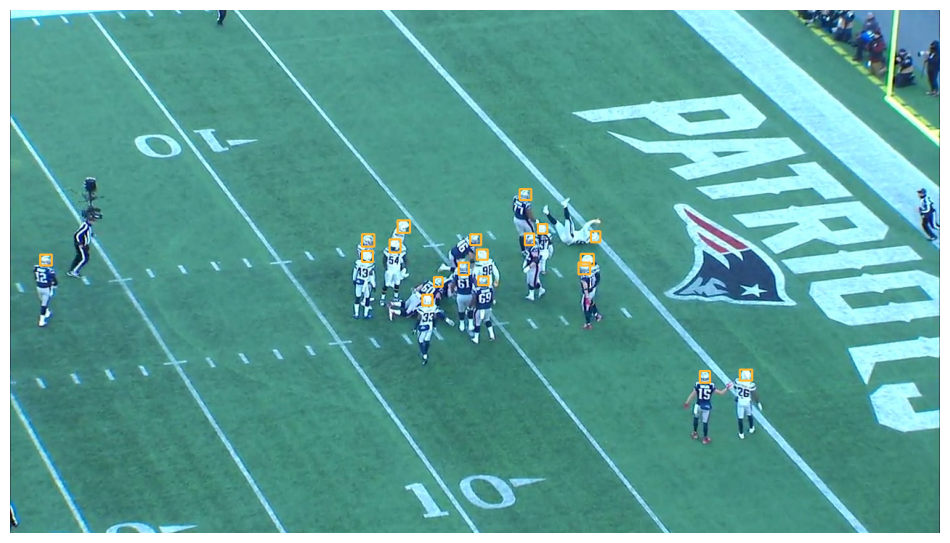

In [9]:
N_SAMPLE = 2
for view, split in itertools.product(['Endzone', 'Sideline'], ['train', 'valid']):
    print(f'Plotting a sample {N_SAMPLE} samples from {view} ({split})')
    samples = np.random.choice(glob.glob(os.path.join(DATASET_DIR, view, 'images', split, '*.jpg')),
                               size=N_SAMPLE, replace=False)
    # For each sample, we will get the equivalent bounding box file,
    # and set up a detections and box annotator objects
    for sample in samples:
        # Read the bounding box from the text file,
        # remove the first column with the ID
        bounding_box = np.loadtxt(os.path.join(
            DATASET_DIR,
            view,
            'labels',
            split,
            f'{os.path.basename(os.path.splitext(sample)[0])}.txt')
        )[:, 1:]
        # Read the image
        image = cv2.imread(sample)
        height, width = image.shape[:2]
        # We need xyxy (in absolute pixel terms), not xy width height (in noramlized terms)
        bounding_box[:, [0, 2]] *= width
        bounding_box[:, [1, 3]] *= height
        # x and y are centers at the moment, convert to
        # top-left and bottom-right
        bounding_box[:, 0] -= bounding_box[:, 2] / 2
        bounding_box[:, 1] -= bounding_box[:, 3] / 2
        bounding_box[:, 2] += bounding_box[:, 0]  # The first and second column now have the top-left corner
        bounding_box[:, 3] += bounding_box[:, 1]
        # Round everything to the nearest integer, and clip to the width and height
        bounding_box = np.round(bounding_box).astype(int)
        # Clip the x coords to be between 0 and width, and y for 0 and height
        bounding_box[:, [0, 2]] = np.clip(bounding_box[:, [0, 2]], 0, width)
        bounding_box[:, [1, 3]] = np.clip(bounding_box[:, [1, 3]], 0, height)

        # Create a Detections object to have the bounding boxes,
        # and attach it to a BoxAnnotator
        detections = sv.Detections(
            bounding_box,
            class_id=np.zeros(bounding_box.shape[0], dtype=int) + 4,  # Just controlling the color of the box
        )
        box_annotator = sv.BoxAnnotator()
        annotated_frame = box_annotator.annotate(
            scene=image.copy(),
            detections=detections
        )
        sv.plot_image(annotated_frame)
    print()

# Train Model
All the image and label data has been set up to train a YOLO model. The only thing left is to generate the YAML config that YOLO needs to locate the images and labels. After that, we call the train method within `ultralytics` and run for a few epochs.

In [10]:
model = YOLO('yolo11n.pt')
OUTPUT_PATH = os.path.join(DATASET_DIR, 'outputs')
os.makedirs(OUTPUT_PATH, exist_ok=True)

In [13]:
data_config = {
    'path': os.path.join(DATASET_DIR, 'Endzone'),
    'train': 'images/train',
    'val': 'images/valid',
    'test': '',
    'names': {
        '0': 'helmet'
    }
}
with open(os.path.join(DATASET_DIR, 'endzone.yaml'), 'w') as f:
    yaml.dump(data_config, f)

In [13]:
model.train(
    data=os.path.join(DATASET_DIR, 'endzone.yaml'),
    epochs=5,
    batch_size=4,
    imgsz=640,
    device='mps',
    rect=True,
    val=True,
    plots=True,
    output_dir=OUTPUT_PATH,
    workers=1
)

AssertionError: 

AssertionError: 